# Predicting Hotel Reservation Cancellations?
## Using data to plan confirmation contacts

**CIS 8005 project presentation - Connor / Jalen**

**Our question:** Can a hotel use reservation information to decide which bookings need a confirmation contact?

**Our recommendation:** Employees confirm data is available before engaging the contact program. The model can identify risk in this sample, but doesn't show that contacting guests prevents cancellations.


In [1]:
# Libraries for data, plots, splitting, models, and evaluation.
from pathlib import Path
import json
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.calibration import CalibrationDisplay
from sklearn.inspection import permutation_importance

In [2]:
# Use the repository root and one fixed seed for reproducible figures.
ROOT = Path(r'C:\Users\jalen\Desktop\workspace\cancellations')
OUT = Path.cwd() / 'graduate_results'
OUT.mkdir(parents=True, exist_ok=True)
SEED = 42
COLORS = {'navy': '#15344A', 'teal': '#167E88', 'amber': '#B46721',
          'gray': '#647780', 'light': '#E6EEF2'}
plt.rcParams.update({
    'figure.dpi': 115, 'savefig.dpi': 170, 'font.size': 12,
    'axes.titlesize': 15, 'axes.labelsize': 12,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'axes.titlepad': 14,
})
pd.set_option('display.max_columns', 20)

def finish(fig, filename):
    """Save the evidence figure and display it inside the notebook."""
    fig.savefig(OUT / filename, bbox_inches='tight')
    plt.show()



In [3]:
# Confirm the target and row IDs before creating any model features.
raw = pd.read_csv(ROOT / 'data/raw/train.csv')
assert raw['booking_status'].isin([0, 1]).all()
assert raw['id'].is_unique
versions = {'python': platform.python_version(), 'numpy': np.__version__,
            'pandas': pd.__version__, 'sklearn': sklearn.__version__}
print('Environment:', versions)
print(f'Raw data: {raw.shape[0]:,} rows and {raw.shape[1]} columns')
(OUT / 'versions.json').write_text(json.dumps(versions, indent=2))

Environment: {'python': '3.14.6', 'numpy': '2.4.6', 'pandas': '3.0.3', 'sklearn': '1.9.0'}
Raw data: 42,100 rows and 19 columns


87

## 2. Check and Prep

We check the data before fitting a model. No missing values or duplicate records require removal. Some records have unusual values, so we retain them and add flags.

| Preparation choice | Why we made it |
|---|---|
| Add total guests and total nights | Make the reservation easier to describe |
| Flag invalid dates and zero values | Keep uncertain records visible without guessing their meaning |
| Exclude the ID and the outcome from predictors | Avoid using an arbitrary identifier or giving the model the answer |
| Encode meal, room and market categories | Their codes represent groups, not measured quantities |


In [4]:
# Add simple totals and indicators while preserving original fields.
def add_features(frame):
    frame = frame.copy()
    frame['total_guests'] = frame.no_of_adults + frame.no_of_children
    frame['total_nights'] = frame.no_of_weekend_nights + frame.no_of_week_nights
    arrival = pd.to_datetime({'year': frame.arrival_year,
                             'month': frame.arrival_month,
                             'day': frame.arrival_date}, errors='coerce')
    frame['invalid_arrival_date'] = arrival.isna().astype(int)
    frame['zero_guests'] = frame.total_guests.eq(0).astype(int)
    frame['zero_nights'] = frame.total_nights.eq(0).astype(int)
    frame['zero_room_price'] = frame.avg_price_per_room.eq(0).astype(int)
    return frame

In [5]:
# Count data-quality patterns before deciding whether to transform them.
train = add_features(raw)
assert train[raw.columns].equals(raw)  # Original values remain unchanged.
y = train['booking_status'].astype(int)
X = train.drop(columns=['id', 'booking_status'])
categories = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']
flags = ['invalid_arrival_date', 'zero_guests', 'zero_nights', 'zero_room_price']
audit = pd.DataFrame({'condition': ['Missing cells', 'Duplicates excluding ID', *flags],
                     'count': [raw.isna().sum().sum(), raw.drop(columns='id').duplicated().sum(),
                               *train[flags].sum().tolist()]})
display(audit)


,condition,count
0,Missing cells,0
1,Duplicates excluding ID,0
2,invalid_arrival_date,50
3,zero_guests,16
4,zero_nights,114
5,zero_room_price,641


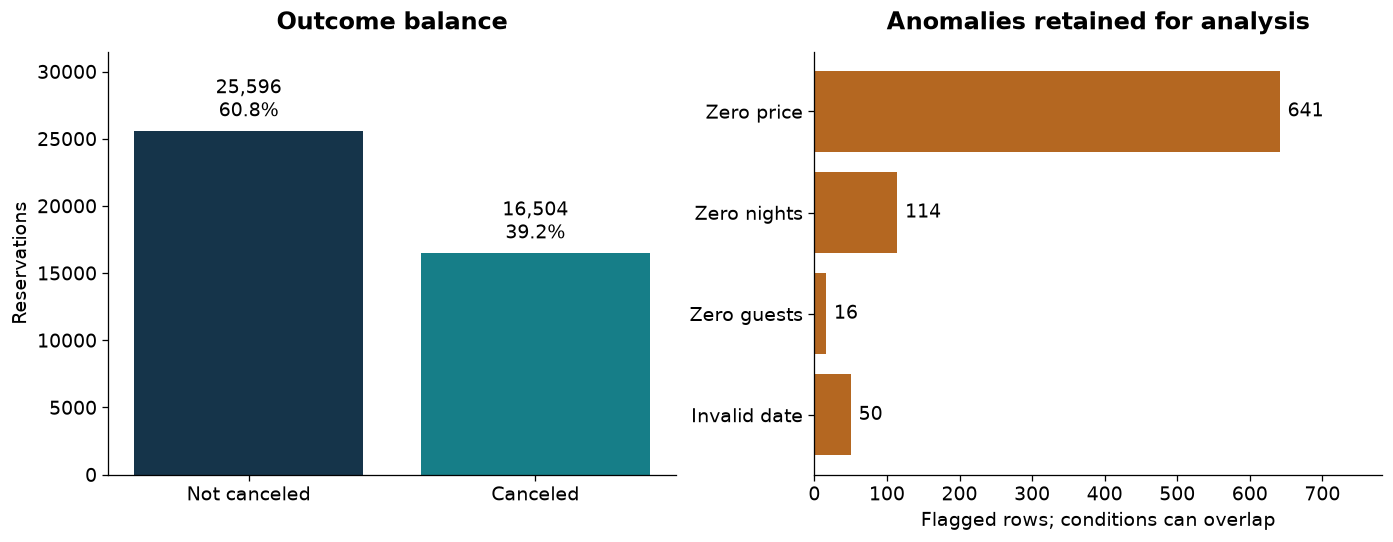

In [6]:
# Show class balance and anomaly frequency side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
counts = y.value_counts().reindex([0, 1])
bars = axes[0].bar(['Not canceled', 'Canceled'], counts,
                   color=[COLORS['navy'], COLORS['teal']])
axes[0].bar_label(bars, labels=[f'{n:,}\n{n/len(y):.1%}' for n in counts], padding=5)
axes[0].set_ylim(0, counts.max()*1.23)
axes[0].set_ylabel('Reservations')
axes[0].set_title('Outcome balance')
flag_counts = train[flags].sum()
bars = axes[1].barh(['Invalid date', 'Zero guests', 'Zero nights', 'Zero price'],
                    flag_counts, color=COLORS['amber'])
axes[1].bar_label(bars, padding=5)
axes[1].set_xlim(0, flag_counts.max()*1.22)
axes[1].set_xlabel('Flagged rows; conditions can overlap')
axes[1].set_title('Anomalies retained for analysis')
finish(fig, '01_data_audit.png')

**What this means:** About **39% canceled and 61% did not**. A model that always predicts “not canceled” would already be correct about 61% of the time. We need measures that show how well it finds cancellations.

The anomaly counts can overlap. A zero price does not automatically mean an error, so we do not delete those bookings without more information.

## 3. Booking Pattern

We compare cancellation rates across lead time groups. Counts appear with the labels so a small group does not look as convincing as a large group. The short vertical lines indicate statistical uncertainty under an independent record assumption.


In [7]:
# Show cancellation rates with Wilson intervals for each lead-time group.
def wilson(successes, n, z=1.96):
    """Wilson interval for a binomial proportion, assuming independent rows."""
    rate = successes / n
    denom = 1 + z*z/n
    center = (rate + z*z/(2*n)) / denom
    half = z*np.sqrt(rate*(1-rate)/n + z*z/(4*n*n)) / denom
    return center-half, center+half

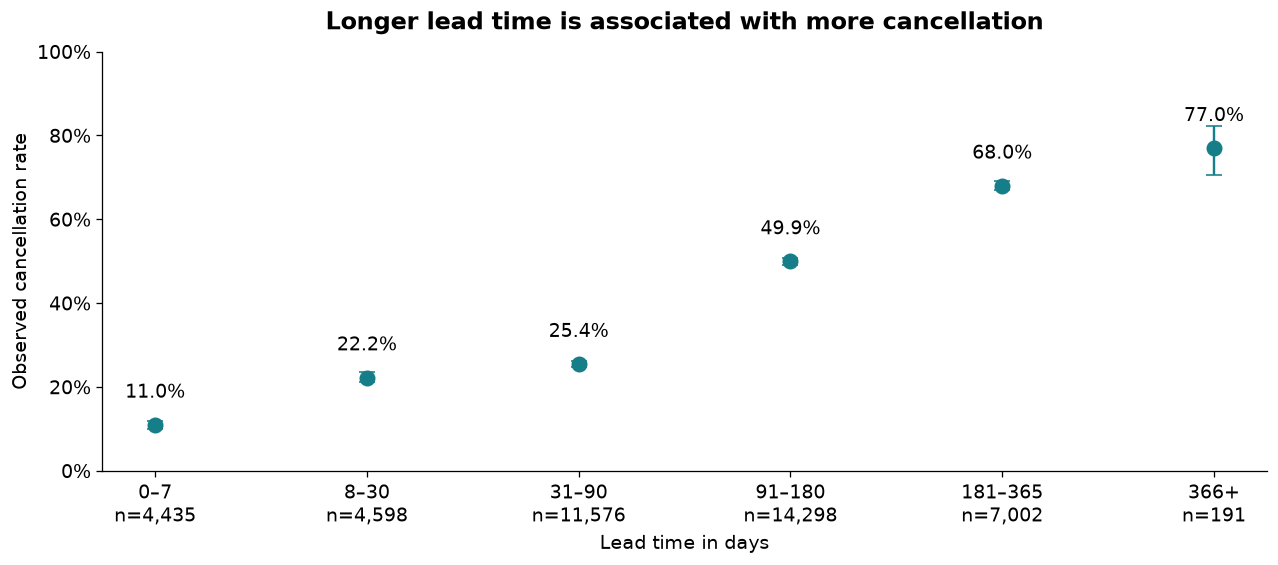

,n,canceled,rate
lead_time,,,
0–7,4435,486,0.1096
8–30,4598,1023,0.2225
31–90,11576,2946,0.2545
91–180,14298,7141,0.4994
181–365,7002,4761,0.6799
366+,191,147,0.7696


In [8]:
# Group bookings by how far ahead they were made, then count cancellations.
lead_band = pd.cut(train.lead_time, [-1, 7, 30, 90, 180, 365, np.inf],
                   labels=['0–7', '8–30', '31–90', '91–180', '181–365', '366+'])
lead = train.groupby(lead_band, observed=True).booking_status.agg(
    n='size', canceled='sum', rate='mean')
lo, hi = wilson(lead.canceled, lead.n)
fig, ax = plt.subplots(figsize=(11, 4.8), constrained_layout=True)
positions = np.arange(len(lead))
ax.errorbar(positions, lead.rate, yerr=[lead.rate-lo, hi-lead.rate],
            fmt='o', markersize=9, capsize=5, color=COLORS['teal'])
ax.set_xticks(positions, [f'{label}\nn={n:,}' for label, n in zip(lead.index, lead.n)])
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.set_xlabel('Lead time in days')
ax.set_ylabel('Observed cancellation rate')
ax.set_title('Longer lead time is associated with more cancellation')
for i, rate in enumerate(lead.rate):
    ax.annotate(f'{rate:.1%}', (i, rate), xytext=(0, 17),
                textcoords='offset points', ha='center')
finish(fig, '02_lead_time_uncertainty.png')
display(lead.round(4))

**What this means:** Longer lead times are associated with more cancellations. This makes lead time a promising predictor. The longest lead time group is small, with only 191 records.

This relationship does not prove that longer lead time causes cancellation. Other booking differences may contribute. Special requests and market segment may also affect the outcome.

## 4. Fair Evaluation

We give each group of records a different job:

| Data group | Size | Job |
|---|---:|---|
| Training | 25,260 | Teach and compare the models |
| Validation | 8,420 | Choose when the model should raise an alert |
| Holdout | 8,420 | Measure the fixed model and alert rule |


In [9]:
# Reserve fitting, cutoff-selection, and final-evaluation rows.
X_dev, X_hold, y_dev, y_hold = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)
X_fit, X_val, y_fit, y_val = train_test_split(
    X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=SEED)
assert set(X_fit.index).isdisjoint(X_val.index)
assert set(X_dev.index).isdisjoint(X_hold.index)
split_summary = pd.DataFrame([
    {'partition': name, 'rows': len(labels), 'cancellation_rate': labels.mean()}
    for name, labels in [('training', y_fit), ('validation', y_val), ('holdout', y_hold)]
])
display(split_summary)
split_summary.to_csv(OUT / 'split_summary.csv', index=False)

,partition,rows,cancellation_rate
0,training,25260,0.392003
1,validation,8420,0.392043
2,holdout,8420,0.392043


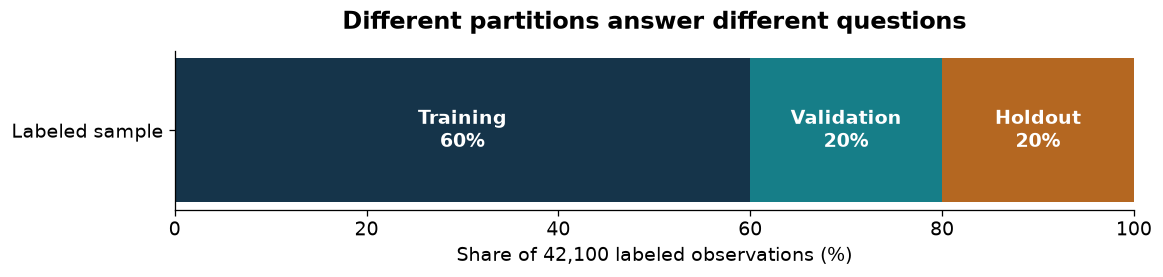

In [10]:
# Visualize the 60/20/20 allocation.
fig, ax = plt.subplots(figsize=(10, 2.3), constrained_layout=True)
left = 0
for name, amount, color in [('Training', 60, COLORS['navy']),
                             ('Validation', 20, COLORS['teal']),
                             ('Holdout', 20, COLORS['amber'])]:
    ax.barh(['Labeled sample'], [amount], left=left, color=color, height=0.45)
    ax.text(left+amount/2, 0, f'{name}\n{amount}%', ha='center', va='center', color='white', weight='bold')
    left += amount
ax.set_xlim(0, 100)
ax.set_xlabel('Share of 42,100 labeled observations (%)')
ax.set_title('Different partitions answer different questions')
finish(fig, '03_validation_design.png')

## 5. Comparing Prediction Methods

We compare three models with a simple baseline:

| Method | Plain language explanation |
|---|---|
| Baseline | Uses the overall cancellation rate, without learning booking patterns |
| Logistic regression | Combines the information in a weighted probability estimate |
| Decision tree | Uses a sequence of branching rules |
| Random forest | Combines the predictions of many trees |

We choose the model using **average precision**, a score that summarizes how well its ranking identifies cancellations. Higher is better. A score of 0.83 is **not** 83% accuracy.


In [11]:
# Fit imputation, scaling, and category encoding inside each training fold.
from sklearn.metrics import make_scorer

def make_preprocessor(columns):
    cats = [c for c in categories if c in columns]
    nums = [c for c in columns if c not in cats]
    return ColumnTransformer([
        ('numeric', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
        ]), nums),
        ('categorical', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), cats),
    ])

def make_model(estimator, columns):
    return Pipeline([('prepare', make_preprocessor(columns)),
                     ('model', clone(estimator))])



In [12]:
# Compare the same four fixed model families with the same folds.
estimators = {
    'Dummy': DummyClassifier(strategy='prior'),
    'Logistic regression': LogisticRegression(max_iter=3000, C=1.0),
    'Decision tree': DecisionTreeClassifier(max_depth=6, min_samples_leaf=30,
                                           random_state=SEED),
    'Random forest': RandomForestClassifier(n_estimators=150,
        min_samples_leaf=5, max_features='sqrt', random_state=SEED, n_jobs=1),
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
scoring = {'roc_auc': 'roc_auc', 'average_precision': 'average_precision',
           'recall': 'recall', 'precision': make_scorer(precision_score, zero_division=0),
           'neg_brier': 'neg_brier_score'}

In [13]:
# Choose the model by training-fold average precision only.
cv_rows = []
fold_scores = {}
for name, estimator in estimators.items():
    result = cross_validate(make_model(estimator, X.columns), X_fit, y_fit,
                            cv=cv, scoring=scoring, n_jobs=1)
    fold_scores[name] = result['test_average_precision']
    cv_rows.append({
        'model': name,
        'mean_AP': result['test_average_precision'].mean(),
        'sd_AP': result['test_average_precision'].std(ddof=1),
        'mean_ROC_AUC': result['test_roc_auc'].mean(),
        'mean_precision_at_0.5': result['test_precision'].mean(),
        'mean_recall_at_0.5': result['test_recall'].mean(),
        'mean_Brier': -result['test_neg_brier'].mean(),
    })
comparison = pd.DataFrame(cv_rows).set_index('model').sort_values('mean_AP', ascending=False)
display(comparison)
comparison.to_csv(OUT / 'training_cv_comparison.csv')
winner = comparison.drop(index='Dummy')['mean_AP'].idxmax()
best = make_model(estimators[winner], X.columns).fit(X_fit, y_fit)
print('Selected by training CV:', winner)
p_val = best.predict_proba(X_val)[:, 1]

,mean_AP,sd_AP,mean_ROC_AUC,mean_precision_at_0.5,mean_recall_at_0.5,mean_Brier
model,,,,,,
Random forest,0.830374,0.002447,0.883957,0.788245,0.721672,0.134304
Decision tree,0.791281,0.004424,0.860172,0.768322,0.713796,0.144302
Logistic regression,0.767816,0.007620,0.843196,0.726434,0.682589,0.156366
Dummy,0.392003,0.000069,0.500000,0.000000,0.000000,0.238337


Selected by training CV: Random forest


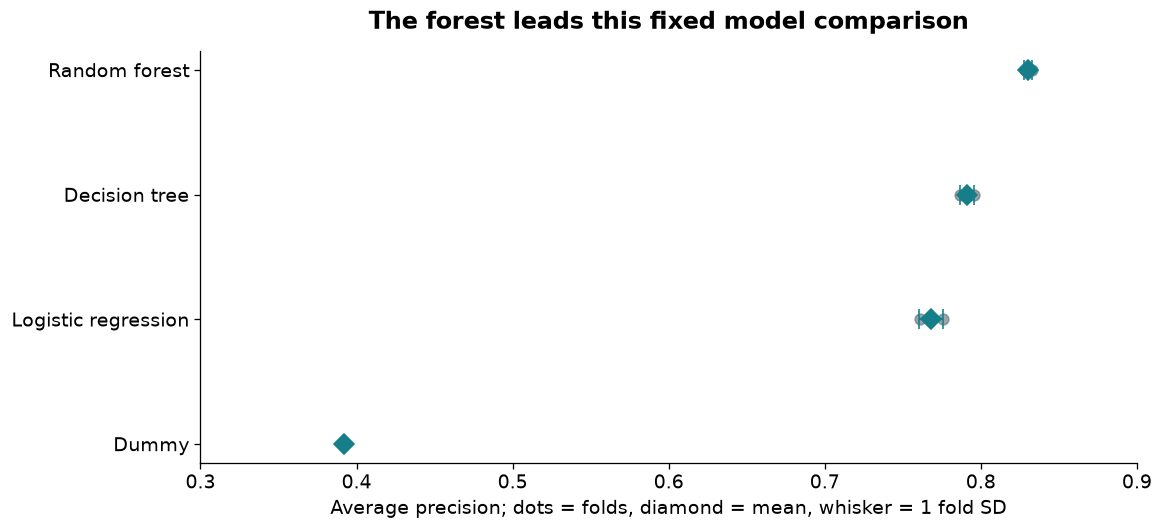

In [14]:
# Plot each fold score so the spread is visible.
order = comparison.index[::-1]
fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
for j, name in enumerate(order):
    scores = fold_scores[name]
    ax.scatter(scores, np.full(len(scores), j), color=COLORS['gray'], alpha=.65, s=45)
    ax.errorbar(scores.mean(), j, xerr=scores.std(ddof=1), fmt='D',
                color=COLORS['teal'], capsize=6, markersize=9)
ax.set_yticks(range(len(order)), order)
ax.set_xlim(.3, .9)
ax.set_xlabel('Average precision; dots = folds, diamond = mean, whisker = 1 fold SD')
ax.set_title('The forest leads this fixed model comparison')
finish(fig, '04_model_comparison.png')

**What this means:** Random forest performs best among these tested settings. Farther right on the chart means a better score. The small dots show the three evaluation rounds, and the diamond shows their average. We use it for the remaining analysis. We have not tested every possible setting or shown that it will be the best model for every hotel.


## 6. When to contact a guest

The model produces a risk estimate. A **threshold** is the cutoff used to raise an alert. For example, a cutoff of 0.50 flags estimates of 50% or higher.

A lower cutoff catches more cancellations but also creates more work.

**Our example assumption:** Missing a cancellation carries five penalty points, while a false alert carries one. These are hypothetical points, not dollars or measured losses.


In [15]:
# Translate probabilities into alert decisions and confusion counts.
def metric_row(labels, probabilities, threshold=0.5):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    return {
        'accuracy': accuracy_score(labels, predictions),
        'precision': precision_score(labels, predictions, zero_division=0),
        'recall': recall_score(labels, predictions, zero_division=0),
        'F1': f1_score(labels, predictions, zero_division=0),
        'ROC_AUC': roc_auc_score(labels, probabilities),
        'AP': average_precision_score(labels, probabilities),
        'Brier': brier_score_loss(labels, probabilities),
        'alert_rate': predictions.mean(), 'TN': int(tn), 'FP': int(fp),
        'FN': int(fn), 'TP': int(tp),
    }

In [16]:
# Use validation rows to choose a cutoff under the stated 5:1 cost assumption.
thresholds = np.r_[np.linspace(0, 1, 201), np.nextafter(1.0, 2.0)]
threshold_rows = []
for t in thresholds:
    pred = p_val >= t
    tn, fp, fn, tp = confusion_matrix(y_val, pred, labels=[0, 1]).ravel()
    threshold_rows.append({'threshold': t, 'FP': fp, 'FN': fn,
                           'alert_rate': pred.mean(), 'loss': fp + 5 * fn})
threshold_table = pd.DataFrame(threshold_rows)
# For tied loss, prefer fewer contacts.
chosen = threshold_table.sort_values(['loss', 'alert_rate']).iloc[0]
threshold = float(chosen['threshold'])
display(chosen.to_frame('chosen validation policy'))
threshold_table.to_csv(OUT / 'validation_thresholds.csv', index=False)

,chosen validation policy
threshold,0.210000
FP,2048.000000
FN,226.000000
alert_rate,0.608432
loss,3178.000000


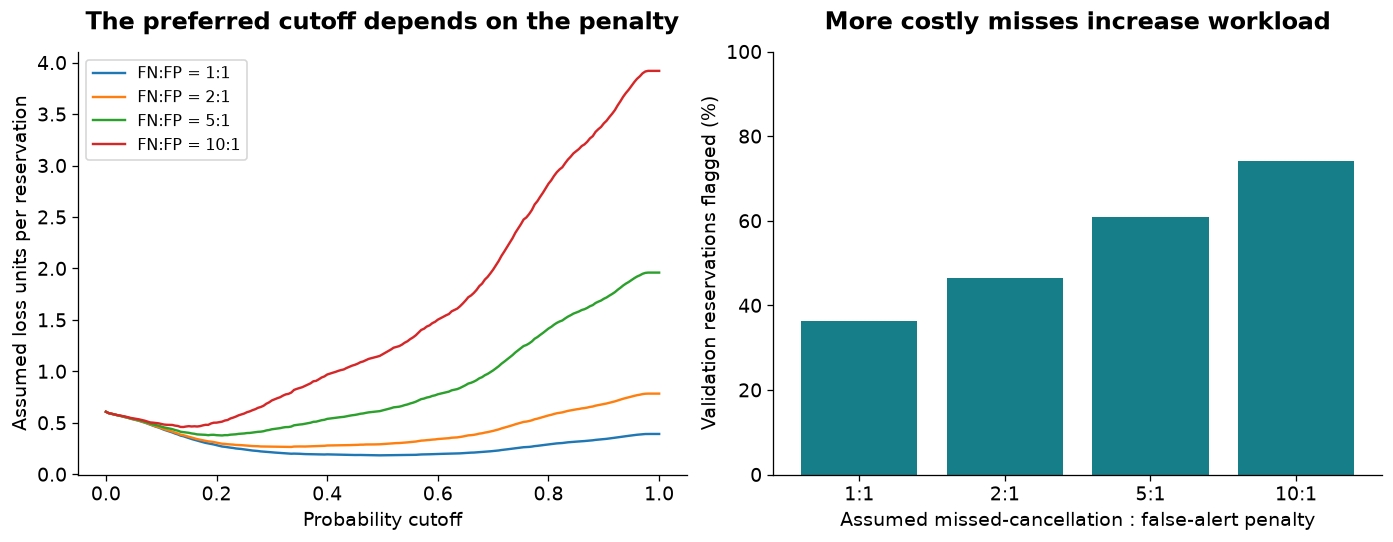

,FN:FP penalty,validation cutoff,validation alert rate
0,1:1,0.49,0.363
1,2:1,0.33,0.464
2,5:1,0.21,0.608
3,10:1,0.14,0.742


In [17]:
# Change the assumed cost ratio to show why the chosen cutoff is conditional.
ratios = [1, 2, 5, 10]
cost_sensitivity = []
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
for ratio in ratios:
    curve = threshold_table.FP + ratio * threshold_table.FN
    selected = (threshold_table.assign(scenario_loss=curve)
                .sort_values(['scenario_loss', 'alert_rate']).iloc[0])
    cost_sensitivity.append({'FN:FP penalty': f'{ratio}:1',
                             'validation cutoff': selected.threshold,
                             'validation alert rate': selected.alert_rate})
    axes[0].plot(threshold_table.threshold, curve/len(y_val), label=f'FN:FP = {ratio}:1')
axes[0].set_xlabel('Probability cutoff')
axes[0].set_ylabel('Assumed loss units per reservation')
axes[0].set_title('The preferred cutoff depends on the penalty')
axes[0].legend(fontsize=10)
scenario = pd.DataFrame(cost_sensitivity)
axes[1].bar(scenario['FN:FP penalty'], 100*scenario['validation alert rate'], color=COLORS['teal'])
axes[1].set_ylim(0, 100)
axes[1].set_xlabel('Assumed missed-cancellation : false-alert penalty')
axes[1].set_ylabel('Validation reservations flagged (%)')
axes[1].set_title('More costly misses increase workload')
finish(fig, '06_cost_assumptions.png')
display(scenario.round(3))

**What this means:** The validation search selects **0.21** under the five-to-one assumption. The extra comparison shows how changing that assumption changes the number of alerts. A hotel with different staffing limits or costs could choose a different rule. A predicted risk of 21% does not tell us whether contacting that guest will help.

## 7. Point of Alerts

We compare the fixed rule with a cutoff of 0.50 on the 8,420 holdout records.

| Term | Question it answers |
|---|---|
| Precision | Of the bookings flagged, how many actually canceled? |
| Recall | Of all bookings that canceled, how many did we flag? |
| Alert rate | What share of bookings would staff need to review? |


In [18]:
# Evaluate the already selected model and policy once on the holdout.
p_hold = best.predict_proba(X_hold)[:, 1]
dummy = make_model(estimators['Dummy'], X.columns).fit(X_fit, y_fit)
holdout = pd.DataFrame({
    'dummy at 0.5': metric_row(y_hold, dummy.predict_proba(X_hold)[:, 1]),
    'selected model at 0.5': metric_row(y_hold, p_hold),
    'selected model at chosen threshold': metric_row(y_hold, p_hold, threshold),
}).T
holdout['illustrative_loss'] = holdout.FP + 5 * holdout.FN
display(holdout)
holdout.to_csv(OUT / 'final_holdout_metrics.csv')
policy_baselines = pd.DataFrame({
    'policy': ['alert nobody', 'alert everybody', 'chosen model threshold'],
    'loss_units': [5 * int(y_hold.sum()), int((y_hold == 0).sum()),
                   int(holdout.loc['selected model at chosen threshold', 'illustrative_loss'])],
})
display(policy_baselines)
policy_baselines.to_csv(OUT / 'holdout_policy_comparison.csv', index=False)

,accuracy,precision,recall,F1,ROC_AUC,AP,Brier,alert_rate,TN,FP,FN,TP,illustrative_loss
dummy at 0.5,0.607957,0.000000,0.000000,0.000000,0.500000,0.392043,0.238345,0.000000,5119.0,0.0,3301.0,0.0,16505.0
selected model at 0.5,0.811401,0.780360,0.722205,0.750157,0.888217,0.835185,0.132696,0.362827,4448.0,671.0,917.0,2384.0,5256.0
selected model at chosen threshold,0.728979,0.598188,0.940321,0.731213,0.888217,0.835185,0.132696,0.616271,3034.0,2085.0,197.0,3104.0,3070.0


,policy,loss_units
0,alert nobody,16505
1,alert everybody,5119
2,chosen model threshold,3070


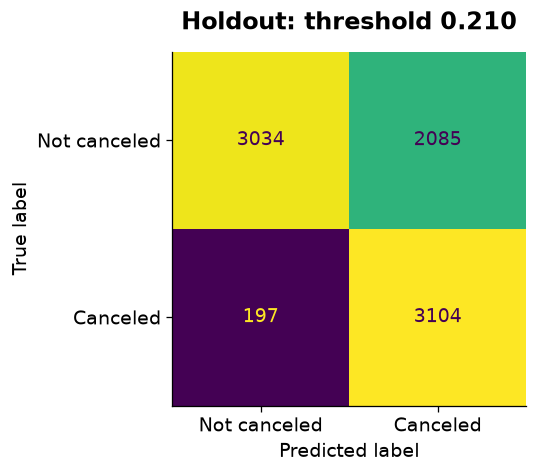

In [19]:
# Show the actual holdout decision counts at the fixed cutoff.
fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
ConfusionMatrixDisplay.from_predictions(y_hold, p_hold >= threshold,
    display_labels=['Not canceled', 'Canceled'], ax=ax, colorbar=False)
ax.set_title(f'Holdout: threshold {threshold:.3f}')
fig.savefig(OUT / 'holdout_confusion_matrix.png', dpi=160)
plt.show()

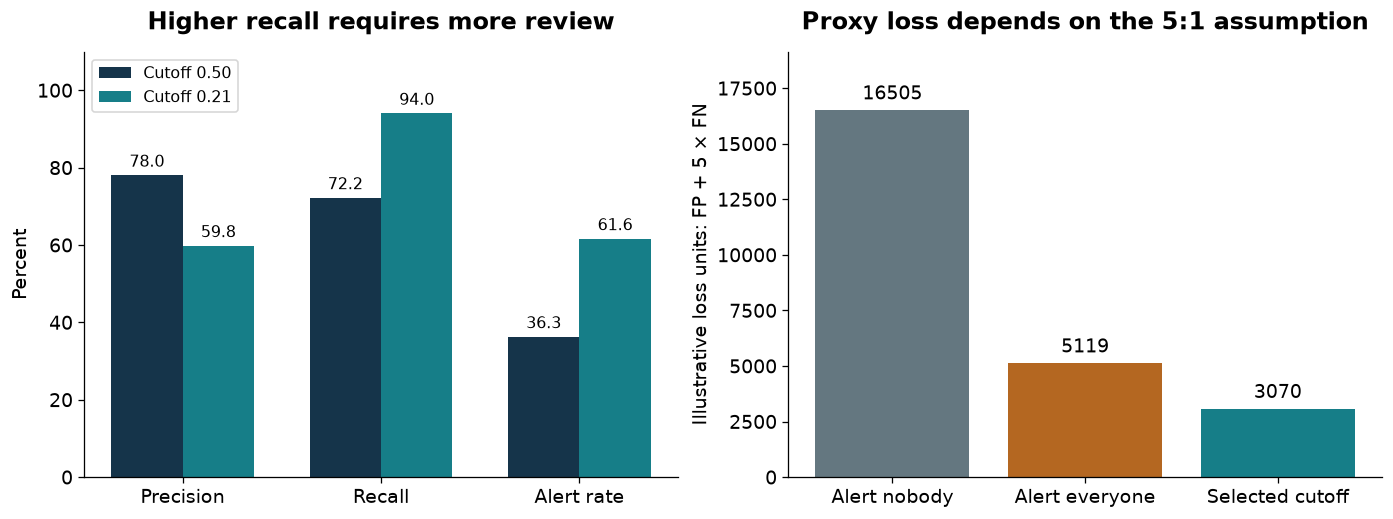

In [20]:
# Compare workload and the illustrative cost with simple policies.
policies = holdout.loc[['selected model at 0.5', 'selected model at chosen threshold']]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)
xx = np.arange(3)
for i, (name, row) in enumerate(policies.iterrows()):
    values = row[['precision', 'recall', 'alert_rate']].to_numpy(dtype=float)*100
    bars = axes[0].bar(xx+(i-.5)*.36, values, width=.36,
        label='Cutoff 0.50' if i==0 else f'Cutoff {threshold:.2f}',
        color=COLORS['navy'] if i==0 else COLORS['teal'])
    axes[0].bar_label(bars, fmt='%.1f', fontsize=10, padding=3)
axes[0].set_xticks(xx, ['Precision', 'Recall', 'Alert rate'])
axes[0].set_ylim(0, 110)
axes[0].set_ylabel('Percent')
axes[0].set_title('Higher recall requires more review')
axes[0].legend(loc='upper left', fontsize=10)
bars = axes[1].bar(['Alert nobody', 'Alert everyone', 'Selected cutoff'], policy_baselines.loss_units,
                  color=[COLORS['gray'], COLORS['amber'], COLORS['teal']])
axes[1].bar_label(bars, padding=4, fmt='%.0f')
axes[1].set_ylim(0, policy_baselines.loss_units.max()*1.16)
axes[1].set_ylabel('Illustrative loss units: FP + 5 × FN')
axes[1].set_title('Proxy loss depends on the 5:1 assumption')
finish(fig, '10_holdout_policy_comparison.png')

**What this means:** the lower cutoff detects about **94% of cancellations**, but it flags about **62% of all bookings**. Roughly **60% of those alerts** are actual cancellations.

On this holdout, the lower cutoff produces 2,085 false alerts and misses 197 cancellations. Staff capacity therefore matters as much as the model score. None of these counts demonstrates cancellations prevented by contact.

## 8. Model Struggles

We also train the selected type of model on 2017 arrivals and evaluate it on 2018 arrivals.

The comparison includes **ROC AUC**, a ranking score. A value of 0.50 represents random ranking and 1.00 represents perfect ranking. It is not an accuracy percentage.

**Code in plain language:** create valid calendar dates, fit a fresh model using the earlier year, then evaluate it in the later year. The second chart shows that the share of canceled bookings also differs between years.

In [21]:
# Train on valid-date 2017 arrivals and test on 2018 arrivals.
arrival = pd.to_datetime({'year': train.arrival_year, 'month': train.arrival_month,
                         'day': train.arrival_date}, errors='coerce')
early = arrival.notna() & train.arrival_year.eq(2017)
later = arrival.notna() & train.arrival_year.eq(2018)
year_model = make_model(estimators[winner], X.columns).fit(X.loc[early], y.loc[early])
p_later = year_model.predict_proba(X.loc[later])[:, 1]
year_stress = pd.DataFrame([metric_row(y.loc[later], p_later, 0.5)])
year_stress['training_rows'] = int(early.sum())
year_stress['evaluation_rows'] = int(later.sum())
year_stress['training_cancellation_rate'] = y.loc[early].mean()
year_stress['evaluation_cancellation_rate'] = y.loc[later].mean()
year_stress['invalid_dates_excluded'] = int(arrival.isna().sum())
display(year_stress)
year_stress.to_csv(OUT / 'arrival_year_stress_test.csv', index=False)

,accuracy,precision,recall,F1,ROC_AUC,AP,Brier,alert_rate,TN,FP,FN,TP,training_rows,evaluation_rows,training_cancellation_rate,evaluation_cancellation_rate,invalid_dates_excluded
0,0.668231,0.770469,0.32007,0.452261,0.769996,0.707588,0.206174,0.177773,19126,1469,10475,4931,6049,36001,0.179368,0.427933,50


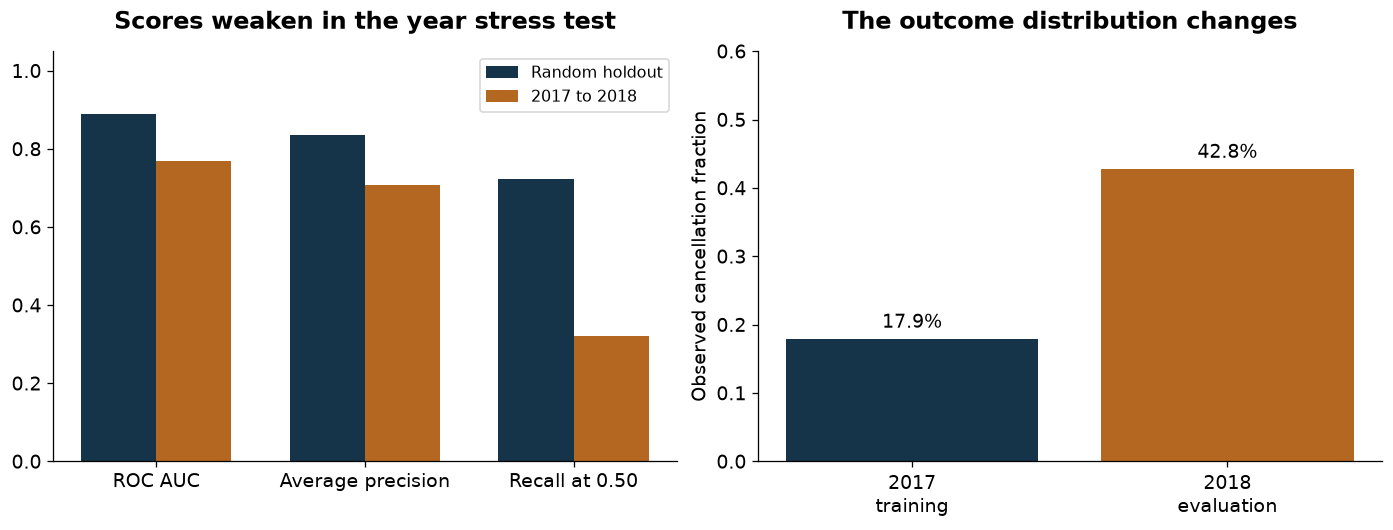

In [22]:
# Compare the temporal stress result with the random holdout.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
metric_names = ['ROC AUC', 'Average precision', 'Recall at 0.50']
random_values = [roc_auc_score(y_hold, p_hold), average_precision_score(y_hold, p_hold),
                 recall_score(y_hold, p_hold>=.5)]
year_values = [year_stress.ROC_AUC.iloc[0], year_stress.AP.iloc[0], year_stress.recall.iloc[0]]
xx = np.arange(3)
axes[0].bar(xx-.18, random_values, .36, label='Random holdout', color=COLORS['navy'])
axes[0].bar(xx+.18, year_values, .36, label='2017 to 2018', color=COLORS['amber'])
axes[0].set_xticks(xx, metric_names)
axes[0].set_ylim(0,1.05)
axes[0].set_title('Scores weaken in the year stress test')
axes[0].legend(fontsize=10)
prev = [y.loc[early].mean(), y.loc[later].mean()]
bars = axes[1].bar(['2017\ntraining', '2018\nevaluation'], prev, color=[COLORS['navy'], COLORS['amber']])
axes[1].bar_label(bars, labels=[f'{v:.1%}' for v in prev], padding=4)
axes[1].set_ylim(0,.6)
axes[1].set_ylabel('Observed cancellation fraction')
axes[1].set_title('The outcome distribution changes')
finish(fig, '12_year_stress_test.png')

**What this means:** The score falls from about **0.89 to 0.77**. The earlier training group is much smaller, and the later group has more cancellations. This comparison changes several things at once, so it does not isolate the effect of time.

Three limits affect our recommendation:

1. **Synthetic data:** results may not transfer to a real hotel.
2. **Information timing:** special requests and booking history must exist when scoring occurs.
3. **Changing conditions:** new bookings may differ from the records used to train the model.

The year check reuses records from the earlier analysis. Arrival dates alone do not establish when cancellation outcomes became known.

## 9. Contact Rule for Staff Capacity

Instead of contacting everyone above a fixed cutoff, staff could review a limited share of the highest-risk bookings.

**Illustration:** compare reviewing different shares of the highest-risk bookings in a batch. Focus on the 10%, 20% and 30% rows in the table. This uses validation data and is an example for planning, not an adopted hotel policy.

**Code in plain language:** sort bookings from highest to lowest risk, select the allowed number, and count the cancellations within that selection.

In [23]:
# Sort validation bookings by score and summarize several review capacities.
# Stable sorting makes ties reproducible. This is a batch ranking illustration.
ranked = np.argsort(-p_val, kind='stable')
capacity_rows = []
for fraction in [.05, .10, .20, .30, .50, 1.0]:
    k = max(1, int(np.ceil(fraction*len(y_val))))
    caught = y_val.to_numpy()[ranked[:k]].sum()
    capacity_rows.append({'review share': k/len(y_val), 'contacts': k,
                          'precision': caught/k, 'recall': caught/y_val.sum(),
                          'lift over random': (caught/k)/y_val.mean()})
capacity = pd.DataFrame(capacity_rows)

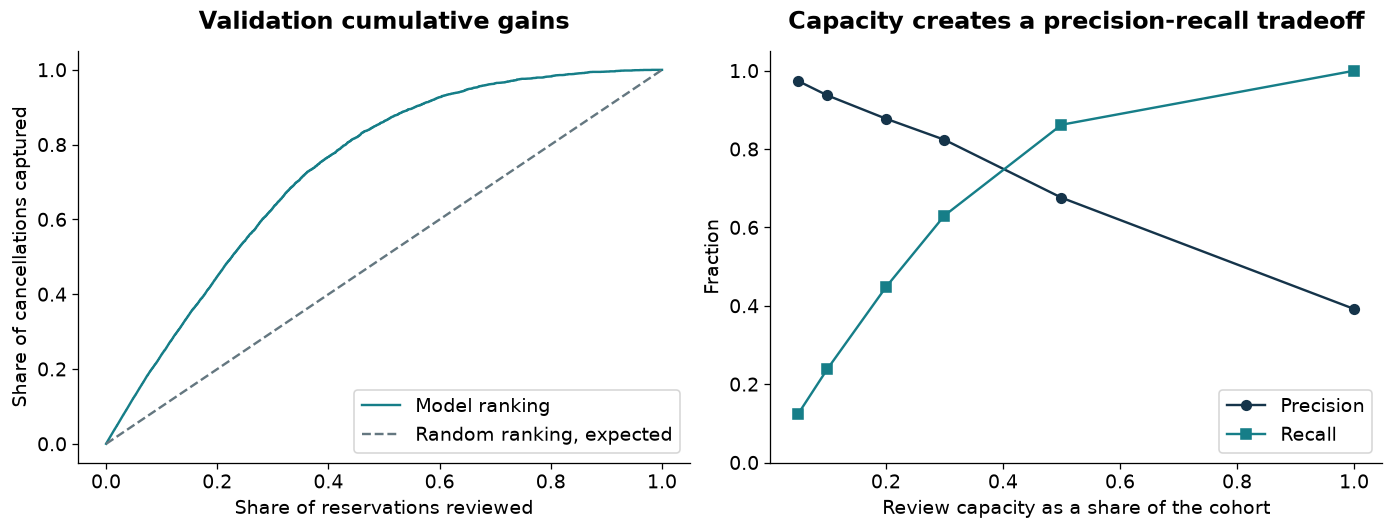

,review share,contacts,precision,recall,lift over random
0,0.05,421,0.974,0.124,2.484
1,0.10,842,0.937,0.239,2.390
2,0.20,1684,0.878,0.448,2.239
3,0.30,2526,0.824,0.630,2.101
4,0.50,4210,0.676,0.862,1.724
5,1.00,8420,0.392,1.000,1.000


In [24]:
# Show how many cancellations a limited review queue could cover.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
review_share = np.arange(1, len(y_val)+1)/len(y_val)
cumulative_recall = np.cumsum(y_val.to_numpy()[ranked])/y_val.sum()
axes[0].plot(review_share, cumulative_recall, color=COLORS['teal'], label='Model ranking')
axes[0].plot([0,1], [0,1], '--', color=COLORS['gray'], label='Random ranking, expected')
axes[0].set(xlabel='Share of reservations reviewed', ylabel='Share of cancellations captured',
            title='Validation cumulative gains')
axes[0].legend()
axes[1].plot(capacity['review share'], capacity.precision, 'o-', label='Precision', color=COLORS['navy'])
axes[1].plot(capacity['review share'], capacity.recall, 's-', label='Recall', color=COLORS['teal'])
axes[1].set(xlabel='Review capacity as a share of the cohort', ylabel='Fraction', ylim=(0,1.05),
            title='Capacity creates a precision-recall tradeoff')
axes[1].legend()
finish(fig, '07_capacity_tradeoffs.png')
display(capacity.round(3))
capacity.to_csv(OUT/'validation_capacity.csv', index=False)

**What this means:** Reviewing the highest risk 20% finds about **45% of the validation cancellations**. About **88% of the reviewed bookings** canceled. A limited contact list is more manageable, but it misses more cancellations.

A real policy needs a defined daily list, fair handling of tied scores, actual contact times and new data testing. High cancellation risk does not automatically mean high benefit from outreach.

## 10. Our recommendation

**Test a limited confirmation-contact program before wider use.**

| Proposed action | Responsible role | Evidence to collect |
|---|---|---|
| Check which fields exist when a booking is created | Data analyst with reservations staff | Timestamped examples and usable input fields |
| Score new bookings without acting on the score first | Data analyst | New-data performance and daily alert volume |
| Set a daily review limit that staff can handle | Reservations manager | Available staff time and time per contact |
| Test contact against usual practice among eligible bookings | Pilot team | Cancellation outcomes, contact effort and guest feedback |
| Review the results before expanding | Hotel manager with analyst | Measured benefit, workload and uncertainty |

**Example to discuss, not a final policy:** review the highest-risk 20% of a daily eligible group, subject to a staff-agreed contact cap. Agree on the pilot period, sample size and success measures before launch. The retrospective 20% comparison above does not establish the best real-world capacity.

**Success should mean more than a good prediction score.** Look for a useful change in outcomes relative to usual practice, acceptable staff workload and acceptable guest experience. We cannot claim saved revenue from this dataset.

**Final message:** Model finds useful patterns in this sample. The next step is to test whether staff can turn those predictions into better decisions.

## Source Method

**Notes**

- Code and embedded results are preserved from its verified run. The visible code reproduces the charts when rerun.
- Dataset: [Kaggle Playground Series S3E7](https://www.kaggle.com/competitions/playground-series-s3e7/data). Synthetic provenance follows the project README and handoff report.
- Methods: [scikit-learn pipelines](https://scikit-learn.org/stable/modules/compose.html) and [decision thresholds](https://scikit-learn.org/1.5/modules/classification_threshold.html).

**For rerunning:** Use Python with NumPy, pandas, matplotlib, scikit-learn and IPython. Set `ROOT` to the folder containing `data/raw/train.csv`. Run all code cells in order. Reread the narrative if you change the data or settings because the explanatory text contains results from this analysis. Preprocessing fits inside training folds, with seed 42 used for reproducibility. Settings remain illustrative rather than exhaustively optimized.

### Key terms

| Term | Say it this way |
|---|---|
| **Feature** | A fact about a booking used for prediction. |
| **Target / label** | The answer we are trying to predict: canceled or not. |
| **Cross-validation** | Repeating practice tests within training data to compare models. |
| **Holdout** | Rows set aside for a final check of the chosen approach. |
| **Average precision** | How well cancellations rise toward the top of a risk-ranked list. |
| **Threshold / cutoff** | The score at which a booking gets flagged. |
| **False alert** | A flagged booking that would not cancel. |
| **Missed cancellation** | A canceled booking that was not flagged. |
| **Data leakage** | Using information that would not actually be available when making the prediction. |
| **Prospective pilot** | Testing the proposed contact process on genuinely new bookings. |